# Colorization challenge

Image colorization is a computer vision taks that consists in tranforming black and white (grayscale) images into colorful pictures.

It has real-world applications, mostly related to the restoration of ancient photographs. Here is an example:

![colorization](https://www.absolutegeeks.com/wp-content/uploads/2024/08/teaser-2.jpg)

Building an automatic colorization system is made easy by the abundance of training data. Any dataset of color images can be used as a training set. Input/output pairs can be easily obtained by converting color images to grayscale, and the original image can be used as the reference ground truth during training.

Nevertheless, a good colorization system requires advanced image understanding, since the model needs to recognize an object to render it with the correct color.

## The challenge

This is the solution to a colorization challenge - design and implement the best image colorization system for the provided dataset, which includes 5,000 images of colorful birds.

The average [Peak Signal-to-Noise Ratio](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio) (PSNR) is used as performance measure. It is computed from the Mean Squared Error (MSE) between the reference and the predicted RGB values:
$$
\text{PSNR} = 10 \log_{10} \frac{\text{MAX}^2}{\text{MSE}},
$$
where $\text{MAX}$ is the largest possible value (i.e., pixels must be in the $[0, \text{MAX}]$ range).

Note that
- the larger the PSNR, the better the prediction;
- the PSNR is measured in decibel (dB) and follows a logarithmic scale.

Compute the PSNR for each validation or test image independently, and take the average.

## Setup and Data

The dataset includes 5,000 images of birds.
To simplify the task, images have been reduced to $192 \times 192$ pixels.

The dataset has been divided into a training set of 4,800 images, a validation set of 100 images and a test set of 100 images.

Training and validation include color images. To train the methods, and to evaluate it you must convert them to grayscale, by taking the average of the RGB channels.

Test images are given in grayscale, and the original RGB versions are kept private, and used by Kaggle to rank the solutions.

The following cells download the data and setup the training set.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image

URL = "https://drive.google.com/file/d/1GX6xX-csMVMz_jq9aMzSjbGJujyvmyse/view?usp=sharing"

!gdown --fuzzy -O- "$URL" | tar xf - && echo OK

Downloading...
From (original): https://drive.google.com/uc?id=1GX6xX-csMVMz_jq9aMzSjbGJujyvmyse
From (redirected): https://drive.google.com/uc?id=1GX6xX-csMVMz_jq9aMzSjbGJujyvmyse&confirm=t&uuid=b873ca54-c030-4f7b-a2f0-b082f36ef00f
To: <_io.BufferedWriter name='<stdout>'>
100% 134M/134M [00:01<00:00, 132MB/s]
OK


In [2]:
SIZE          = 128
BATCH_SIZE    = 32
NUM_EPOCHS    = 100
LR            = 2e-4
GEN_FEATURES  = 256
DISPLAY_EVERY = 100   # show images every N epochs

## YCbCr U-Net

Defining the helper functions for a U-Net CNN model that works with images encoded in YCbCr. this encoding is chosen to simplify the work of the model - instead of predicting three values for each class of RGB, the Y channel is exactly the input grayscale images. So only two values have to be predicted by the model.

In [3]:
# Claude was used to generate these functions
def rgb_to_ycbcr(rgb):
    """
    Convert RGB to YCbCr.
    Args:
        rgb: (B, 3, H, W) float tensor in [0, 1]
    Returns:
        y:    (B, 1, H, W) luminance in [0, 1]
        cbcr: (B, 2, H, W) chrominance in [0, 1]
    """
    r, g, b = rgb[:, 0:1], rgb[:, 1:2], rgb[:, 2:3]
    y  =  0.299  * r + 0.587  * g + 0.114  * b
    cb = -0.169  * r - 0.331  * g + 0.500  * b + 0.5
    cr =  0.500  * r - 0.419  * g - 0.081  * b + 0.5
    return y, torch.cat([cb, cr], dim=1)


def ycbcr_to_rgb(y, cbcr):
    """
    Convert YCbCr back to RGB.
    Args:
        y:    (B, 1, H, W) in [0, 1]
        cbcr: (B, 2, H, W) in [0, 1]
    Returns:
        rgb: (B, 3, H, W) in [0, 1]
    """
    cb = cbcr[:, 0:1] - 0.5
    cr = cbcr[:, 1:2] - 0.5
    r = y               + 1.403 * cr
    g = y - 0.344 * cb  - 0.714 * cr
    b = y + 1.773 * cb
    return torch.cat([r, g, b], dim=1).clamp(0, 1)

torch.Size([3, 128, 128]) torch.float32
Train: 4800 images
Val:   100 images


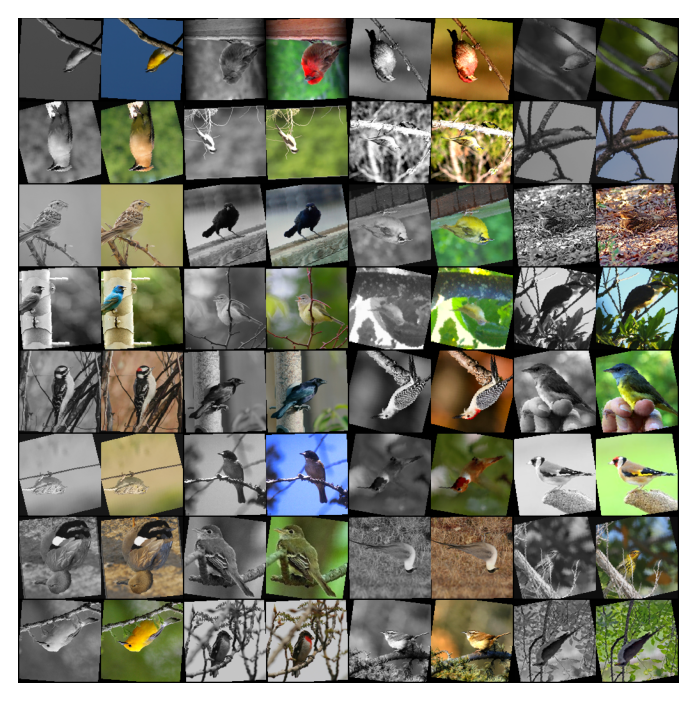

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((SIZE, SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
  torchvision.transforms.Resize(
    (SIZE, SIZE),
    interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
])

training_set = torchvision.datasets.ImageFolder(
    "colorization/train/rgb", transform=train_transform
)
print(training_set[0][0].shape, training_set[0][0].dtype)

training_loader = torch.utils.data.DataLoader(
    training_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, drop_last=True
)

validation_set = torchvision.datasets.ImageFolder(
    "colorization/valid/rgb", transform=val_transform
)
validation_loader = torch.utils.data.DataLoader(
    validation_set, batch_size=50, shuffle=False,
    drop_last=False, num_workers=1
)

print(f"Train: {len(training_set)} images")
print(f"Val:   {len(validation_set)} images")

def show_batch(*imgs):
    plt.figure(dpi=180)
    imgs = [x.expand(-1, 3, -1, -1) for x in imgs]
    imgs = torch.cat(imgs, -1).detach().cpu()
    g = torchvision.utils.make_grid(imgs, nrow=4, value_range=(0, 1))
    plt.imshow(g.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.show()

# Preview a batch
rgb, _ = next(iter(training_loader))
y, _   = rgb_to_ycbcr(rgb)
show_batch(y, rgb)   # grayscale | colour

## Solution

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## U-Net Generator

In [6]:
def downsample_block(inch, outch, batchnorm=True):
    """4x4 strided conv + optional BN + LeakyReLU."""
    seq = torch.nn.Sequential(
        torch.nn.Conv2d(inch, outch, 4, stride=2, padding=1, bias=False),
        torch.nn.LeakyReLU(0.2)
    )
    if batchnorm:
        seq.insert(1, torch.nn.BatchNorm2d(outch))
    return seq


def upsample_block(inch, outch, dropout=False):
    """4x4 transposed conv + BN + optional Dropout + ReLU."""
    seq = torch.nn.Sequential(
        torch.nn.ConvTranspose2d(inch, outch, 4, stride=2, padding=1, bias=False),
        torch.nn.BatchNorm2d(outch),
        torch.nn.ReLU()
    )
    if dropout:
        seq.insert(2, torch.nn.Dropout2d())
    return seq


class Generator(torch.nn.Module):
    """
    U-Net: Y (1ch) → CbCr (2ch)
    ResNet-style addition skip connections.
    """
    def __init__(self, features):
        super().__init__()
        self.down = torch.nn.ModuleList([
            downsample_block(1,             features // 8, batchnorm=False),
            downsample_block(features // 8, features // 4),
            downsample_block(features // 4, features // 2),
            downsample_block(features // 2, features),
            downsample_block(features,      features),
            downsample_block(features,      features),
            downsample_block(features,      features),
        ])
        self.up = torch.nn.ModuleList([
            upsample_block(features,      features,      dropout=True),
            upsample_block(features,      features,      dropout=True),
            upsample_block(features,      features,      dropout=True),
            upsample_block(features,      features // 2, dropout=False),
            upsample_block(features // 2, features // 4, dropout=False),
            upsample_block(features // 4, features // 8, dropout=False),
        ])
        self.final_conv = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(features // 8, 2, 4, stride=2, padding=1),
            torch.nn.Tanh()   # output in [-1, 1]
        )

    def forward(self, x):
        skip = []

        x = self.down[0](x)
        for down in self.down[1:]:
            skip.append(x)
            x = down(x)

        x = self.up[0](x)
        for up in self.up[1:]:
            x = x + skip.pop()
            x = up(x)

        x = x + skip.pop()
        return self.final_conv(x)

In [7]:
generator = Generator(GEN_FEATURES).to(DEVICE)
params = sum(p.numel() for p in generator.parameters())
print(f"Generator: {params:,d} parameters")

# Sanity check
_x = torch.zeros(2, 1, SIZE, SIZE).to(DEVICE)
_y = generator(_x)
print(f"Shape check: {_x.shape} -> {_y.shape}")   # (2,1,128,128) -> (2,2,128,128)

Generator: 7,673,666 parameters
Shape check: torch.Size([2, 1, 128, 128]) -> torch.Size([2, 2, 128, 128])


## Loss, Optimiser and PSNR

The MSE loss is used since it directly maximises PSNR (the evaluation metric of the challenge). Adam optimiser is used.

In [8]:
MSE       = torch.nn.MSELoss()
opt_gen   = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
scheduler = torch.optim.lr_scheduler.StepLR(opt_gen, step_size=30, gamma=0.5)


def average_psnr(output, target):
    """
    Average PSNR over the batch.
    output, target: (B, C, H, W) in [0, 1]
    """
    mse  = torch.mean(torch.flatten((output - target) ** 2, 1), 1)
    psnr = -10 * torch.log10(mse)
    psnr = torch.where(mse == 0, torch.tensor(100.0, device=mse.device), psnr)
    return psnr.mean()


def train_step(rgb):
    """rgb: (B, 3, H, W) in [0, 1]"""
    y, cbcr = rgb_to_ycbcr(rgb)

    # Normalise to [-1, 1] to match Tanh output
    y_n    = y    * 2 - 1
    cbcr_n = cbcr * 2 - 1

    opt_gen.zero_grad()
    pred_n = generator(y_n)
    loss   = MSE(pred_n, cbcr_n)
    loss.backward()
    opt_gen.step()

    return loss.item()

## Training Loop

Epoch  10  PSNR: 22.31 dB  LR: 2.00e-04
Epoch  20  PSNR: 22.58 dB  LR: 2.00e-04
Epoch  30  PSNR: 22.92 dB  LR: 2.00e-04
Epoch  40  PSNR: 22.93 dB  LR: 1.00e-04
Epoch  50  PSNR: 23.10 dB  LR: 1.00e-04
Epoch  60  PSNR: 23.09 dB  LR: 1.00e-04
Epoch  70  PSNR: 23.18 dB  LR: 5.00e-05
Epoch  80  PSNR: 22.98 dB  LR: 5.00e-05
Epoch  90  PSNR: 23.31 dB  LR: 5.00e-05
Epoch 100  PSNR: 23.07 dB  LR: 2.50e-05


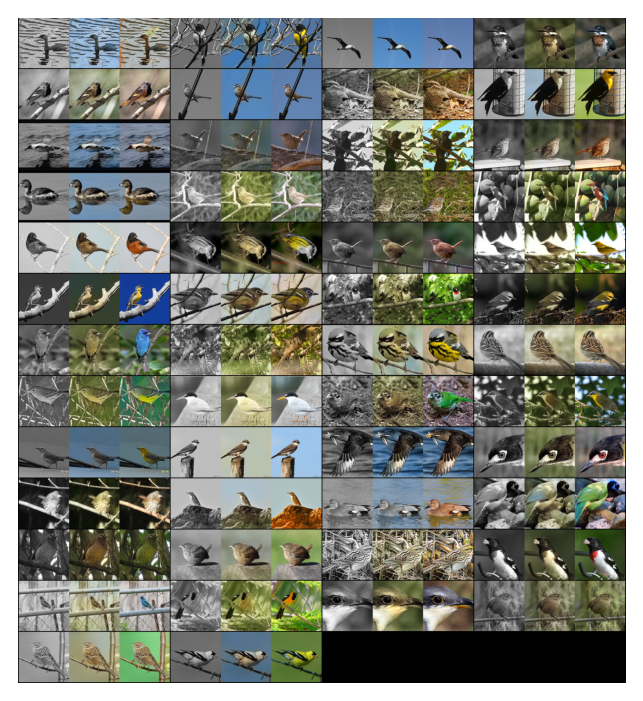

In [9]:
for epoch in range(NUM_EPOCHS):
    generator.train()

    for rgb, _ in training_loader:
        rgb = rgb.to(DEVICE)
        train_step(rgb)

    # Validation
    generator.eval()
    with torch.no_grad():
        tot_psnr = 0.0
        for rgb, _ in validation_loader:
            rgb  = rgb.to(DEVICE)
            y, _ = rgb_to_ycbcr(rgb)

            pred_n    = generator(y * 2 - 1)
            cbcr_pred = (pred_n + 1) / 2
            rgb_pred  = ycbcr_to_rgb(y, cbcr_pred)

            tot_psnr += average_psnr(rgb_pred, rgb).item() * rgb.shape[0]

        psnr = tot_psnr / len(validation_set)
        if (epoch + 1) % 10 == 0:
          print(f"Epoch {epoch+1:3d}  PSNR: {psnr:.2f} dB  LR: {scheduler.get_last_lr()[0]:.2e}")

        # Display every DISPLAY_EVERY epochs
        if (epoch + 1) % DISPLAY_EVERY == 0:
            show_batch(y, rgb_pred, rgb)   # grayscale | predicted | ground truth

    scheduler.step()

## Evaluation

The cell below is used to compute the average PSNR on the validation set.

Final — PSNR: 23.07 dB   MSE: 0.0070


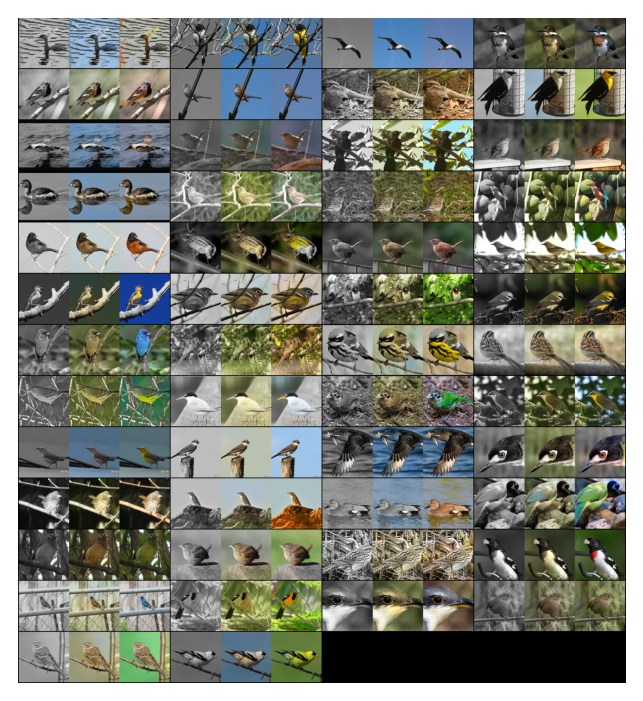

In [10]:
# Final evaluation on the test set
generator.eval()
tot_mse  = 0.0
tot_psnr = 0.0

with torch.no_grad():
    for rgb, _ in validation_loader:
        rgb  = rgb.to(DEVICE)
        y, _ = rgb_to_ycbcr(rgb)

        pred_n    = generator(y * 2 - 1)
        cbcr_pred = (pred_n + 1) / 2
        rgb_pred  = ycbcr_to_rgb(y, cbcr_pred)

        tot_mse  += torch.nn.functional.mse_loss(rgb_pred, rgb).item() * rgb.shape[0]
        tot_psnr += average_psnr(rgb_pred, rgb).item() * rgb.shape[0]

mse  = tot_mse  / len(validation_set)
psnr = tot_psnr / len(validation_set)
print(f"Final — PSNR: {psnr:.2f} dB   MSE: {mse:.4f}")
show_batch(y, rgb_pred, rgb)